In [18]:
# ============================================================
# 0. 라이브러리 불러오기
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay,
roc_auc_score,
roc_curve
)

sns.set_theme(style="whitegrid")

In [19]:
# ============================================================
# 1. 타이타닉 데이터 불러오기
# ============================================================

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("데이터 크기:", df.shape)


데이터 크기: (891, 12)


In [20]:
# ============================================================
# 2. 데이터 기본 확인
# ============================================================

print("\n[상위 5개]")
print(df.head())

print("\n[데이터 정보]")
df.info()

print("\n[수치형 변수 통계]")
print(df.describe())

print("\n[범주형 변수 통계]")
print(df.describe(include="object"))

print("\n[데이터 타입]")
print(df.dtypes)




[상위 5개]
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN     


[컬럼별 결측값 개수]
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

[컬럼별 결측값 비율]
Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


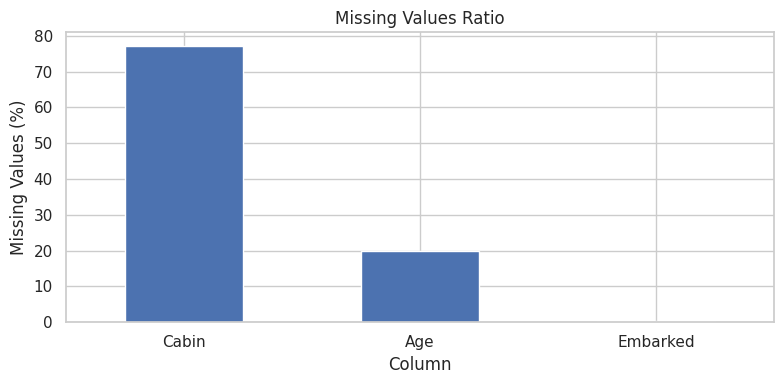

In [21]:
# ============================================================
# 3. 결측값 확인
# ============================================================

print("\n[컬럼별 결측값 개수]")
print(df.isnull().sum())

print("\n[컬럼별 결측값 비율]")
print((df.isnull().mean() * 100).sort_values(ascending=False))


# 결측값 시각화
missing_ratio = df.isnull().mean() * 100
missing_ratio = missing_ratio[missing_ratio > 0]

plt.figure(figsize=(8, 4))
missing_ratio.sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values Ratio")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:


# ============================================================
# 4. 중복값 확인 및 제거
# ============================================================

print("\n중복값 개수:", df.duplicated().sum())

df = df.drop_duplicates().copy()

print("중복 제거 후 데이터 크기:", df.shape)


중복값 개수: 0
중복 제거 후 데이터 크기: (891, 12)



[생존 여부 개수]
Survived
0    549
1    342
Name: count, dtype: int64

[생존 여부 비율]
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


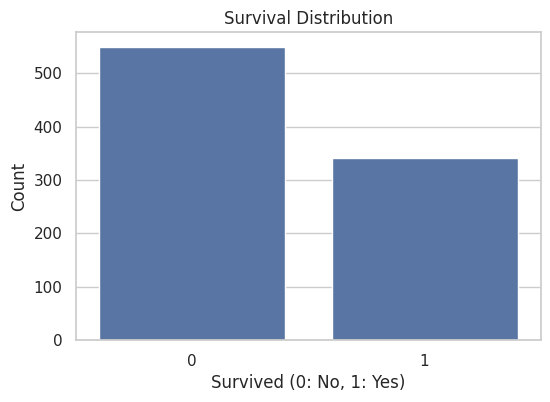

In [23]:

# ============================================================
# 5. 타겟 분포 확인
# ============================================================

print("\n[생존 여부 개수]")
print(df["Survived"].value_counts())

print("\n[생존 여부 비율]")
print(df["Survived"].value_counts(normalize=True))


plt.figure(figsize=(6, 4))

sns.countplot(
data=df,
x="Survived"
)

plt.title("Survival Distribution")
plt.xlabel("Survived (0: No, 1: Yes)")
plt.ylabel("Count")
plt.show()



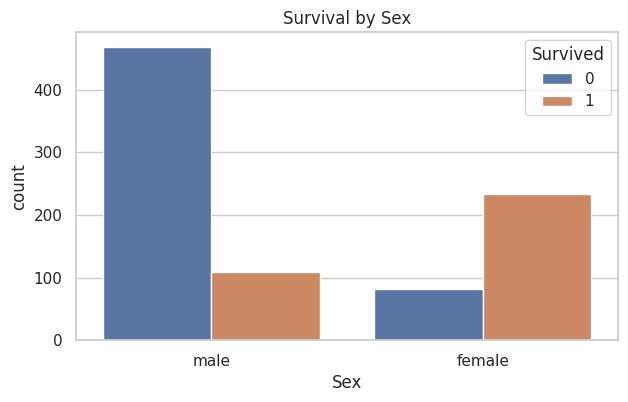

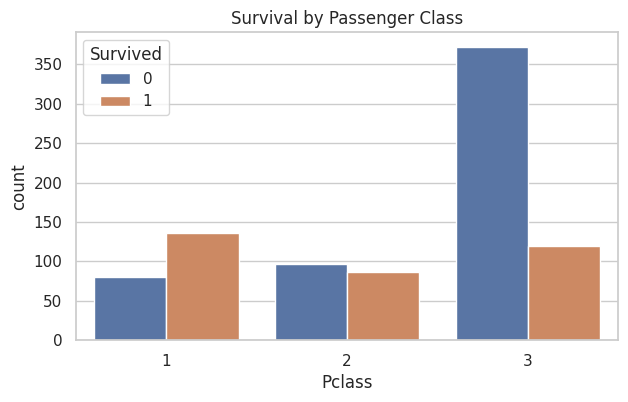

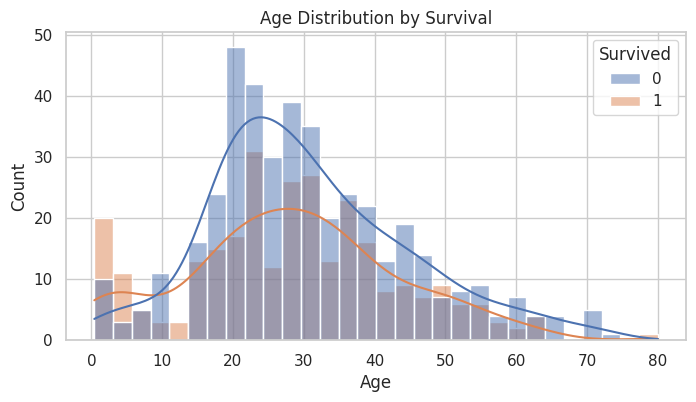

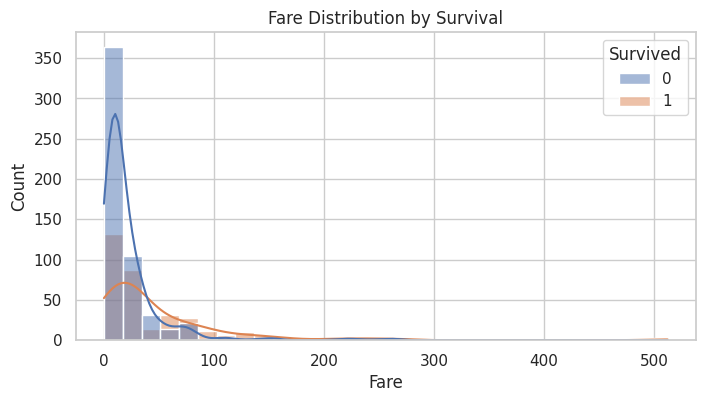

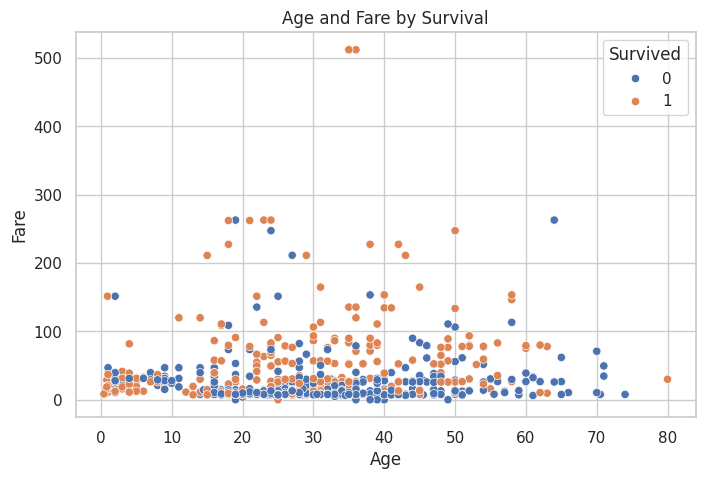

In [24]:
# ============================================================
# 6. 기초 시각화
# ============================================================

# 성별에 따른 생존 여부
plt.figure(figsize=(7, 4))

sns.countplot(
data=df,
x="Sex",
hue="Survived"
)

plt.title("Survival by Sex")
plt.show()


# 객실 등급에 따른 생존 여부
plt.figure(figsize=(7, 4))

sns.countplot(
data=df,
x="Pclass",
hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.show()


# 나이 분포
plt.figure(figsize=(8, 4))

sns.histplot(
data=df,
x="Age",
hue="Survived",
bins=30,
kde=True
)

plt.title("Age Distribution by Survival")
plt.show()


# 탑승 요금 분포
plt.figure(figsize=(8, 4))

sns.histplot(
data=df,
x="Fare",
hue="Survived",
bins=30,
kde=True
)

plt.title("Fare Distribution by Survival")
plt.show()


# 나이와 탑승 요금 관계
plt.figure(figsize=(8, 5))

sns.scatterplot(
data=df,
x="Age",
y="Fare",
hue="Survived"
)

plt.title("Age and Fare by Survival")
plt.show()


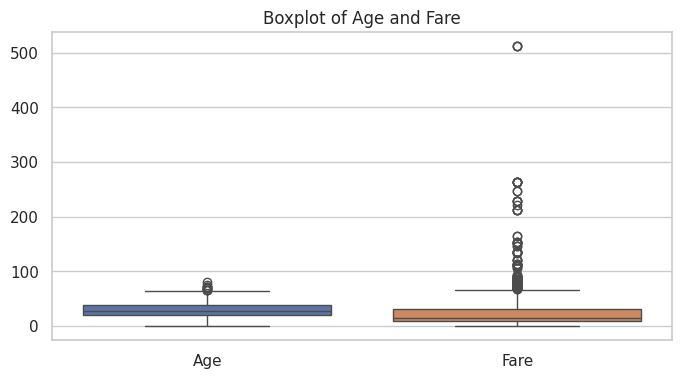


[Age 이상치]
Q1: 20.125
Q3: 38.0
IQR: 17.875
하한: -6.6875
상한: 64.8125
이상치 개수: 11

[Fare 이상치]
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
하한: -26.724
상한: 65.6344
이상치 개수: 116


(np.float64(-26.724), np.float64(65.6344))

In [26]:
# ============================================================
# 7. 이상치 확인
# ============================================================

plt.figure(figsize=(8, 4))

sns.boxplot(
data=df[["Age", "Fare"]]
)

plt.title("Boxplot of Age and Fare")
plt.show()

def check_outlier(dataframe, column):

    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]

    print(f"\n[{column} 이상치]")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("하한:", lower_bound)
    print("상한:", upper_bound)
    print("이상치 개수:", len(outliers))

    return lower_bound, upper_bound


check_outlier(df, "Age")
check_outlier(df, "Fare")


In [27]:


# ============================================================
# 8. 파생변수 생성
# ============================================================

df_processed = df.copy()


# 가족 수
df_processed["FamilySize"] = (
df_processed["SibSp"] +
df_processed["Parch"] +
1
)


# 혼자 탑승했는지 여부
df_processed["IsAlone"] = (
df_processed["FamilySize"] == 1
).astype(int)


# 이름에서 호칭 추출
df_processed["Title"] = df_processed["Name"].str.extract(
r",\s*([^.]*)\.",
expand=False
).str.strip()


# 드문 호칭을 Rare로 통합
rare_titles = [
"Lady", "Countess", "Capt", "Col", "Don",
"Dr", "Major", "Rev", "Sir", "Jonkheer",
"Dona"
]

df_processed["Title"] = df_processed["Title"].replace(
rare_titles,
"Rare"
)


# 유사 호칭 통합
df_processed["Title"] = df_processed["Title"].replace({
"Mlle": "Miss",
"Ms": "Miss",
"Mme": "Mrs"
})


# 객실 정보 존재 여부
df_processed["CabinKnown"] = (
df_processed["Cabin"].notnull()
).astype(int)


print("\n[파생변수 확인]")
print(
df_processed[
[
"FamilySize",
"IsAlone",
"Title",
"CabinKnown"
]
].head()
)


[파생변수 확인]
   FamilySize  IsAlone Title  CabinKnown
0           2        0    Mr           0
1           2        0   Mrs           1
2           1        1  Miss           0
3           2        0   Mrs           1
4           1        1    Mr           0


In [28]:



# ============================================================
# 9. 불필요한 변수 제거
# ============================================================

drop_columns = [
"PassengerId",
"Name",
"Ticket",
"Cabin"
]

df_processed = df_processed.drop(
columns=drop_columns
)

print("\n[남은 컬럼]")
print(df_processed.columns.tolist())



[남은 컬럼]
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'CabinKnown']


In [29]:


# ============================================================
# 10. 입력 변수와 타겟 변수 분리
# ============================================================

X = df_processed.drop(
columns="Survived"
)

y = df_processed["Survived"]

print("\nX 크기:", X.shape)
print("y 크기:", y.shape)


X 크기: (891, 11)
y 크기: (891,)


In [30]:
# ============================================================
# 11. 학습용·테스트용 데이터 분리
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

print("\n학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)


학습 데이터: (712, 11)
테스트 데이터: (179, 11)


In [31]:

# ============================================================
# 12. 결측값 직접 처리
# Pipeline과 SimpleImputer를 사용하지 않음
# ============================================================

# Age: 학습 데이터 중앙값으로 대체
age_median = X_train["Age"].median()

X_train["Age"] = X_train["Age"].fillna(age_median)
X_test["Age"] = X_test["Age"].fillna(age_median)


# Fare: 학습 데이터 중앙값으로 대체
fare_median = X_train["Fare"].median()

X_train["Fare"] = X_train["Fare"].fillna(fare_median)
X_test["Fare"] = X_test["Fare"].fillna(fare_median)


# Embarked: 학습 데이터 최빈값으로 대체
embarked_mode = X_train["Embarked"].mode()[0]

X_train["Embarked"] = X_train["Embarked"].fillna(embarked_mode)
X_test["Embarked"] = X_test["Embarked"].fillna(embarked_mode)


print("\n[결측값 처리 후 학습 데이터]")
print(X_train.isnull().sum())

print("\n[결측값 처리 후 테스트 데이터]")
print(X_test.isnull().sum())



[결측값 처리 후 학습 데이터]
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
Title         0
CabinKnown    0
dtype: int64

[결측값 처리 후 테스트 데이터]
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
Title         0
CabinKnown    0
dtype: int64


In [33]:
# ============================================================
# 13. 이상치 처리
# IQR 범위를 벗어나는 값을 경계값으로 변환
# ============================================================

def outlier_capping(train_data, test_data, column):

    Q1 = train_data[column].quantile(0.25)
    Q3 = train_data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    train_data[column] = train_data[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    test_data[column] = test_data[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    print(f"{column} 이상치 처리 완료")
    print("하한:", lower_bound)
    print("상한:", upper_bound)


outlier_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "FamilySize"
]

for column in outlier_columns:
    outlier_capping(
        X_train,
        X_test,
        column
    )

Age 이상치 처리 완료
하한: 1.0
상한: 57.0
Fare 이상치 처리 완료
하한: -26.7605
상한: 65.6563
SibSp 이상치 처리 완료
하한: -1.5
상한: 2.5
Parch 이상치 처리 완료
하한: 0.0
상한: 0.0
FamilySize 이상치 처리 완료
하한: -0.5
상한: 3.5


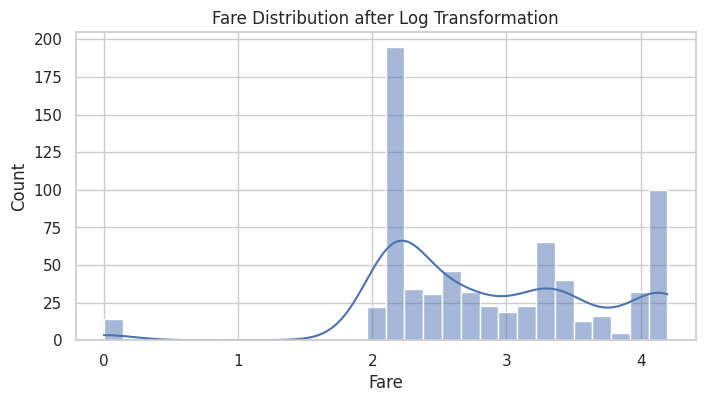

In [34]:
# ============================================================
# 14. 로그 변환
# Fare는 오른쪽으로 치우친 분포이므로 로그 변환
# ============================================================

X_train["Fare"] = np.log1p(X_train["Fare"])
X_test["Fare"] = np.log1p(X_test["Fare"])


plt.figure(figsize=(8, 4))

sns.histplot(
X_train["Fare"],
bins=30,
kde=True
)

plt.title("Fare Distribution after Log Transformation")
plt.show()



[인코딩 후 학습 데이터]
     Pclass   Age  SibSp  Parch      Fare  FamilySize  IsAlone  CabinKnown  \
692       3  28.5    0.0      0  4.051712         1.0        1           0   
481       2  28.5    0.0      0  0.000000         1.0        1           0   
527       1  28.5    0.0      0  4.199550         1.0        1           1   
855       3  18.0    0.0      0  2.336987         2.0        0           0   
801       2  31.0    1.0      0  3.305054         3.0        0           0   

     Sex_male  Embarked_Q  Embarked_S  Title_Miss  Title_Mr  Title_Mrs  \
692         1           0           1           0         1          0   
481         1           0           1           0         1          0   
527         1           0           1           0         1          0   
855         0           0           1           0         0          1   
801         0           0           1           0         0          1   

     Title_Rare  
692           0  
481           0  
527           0 

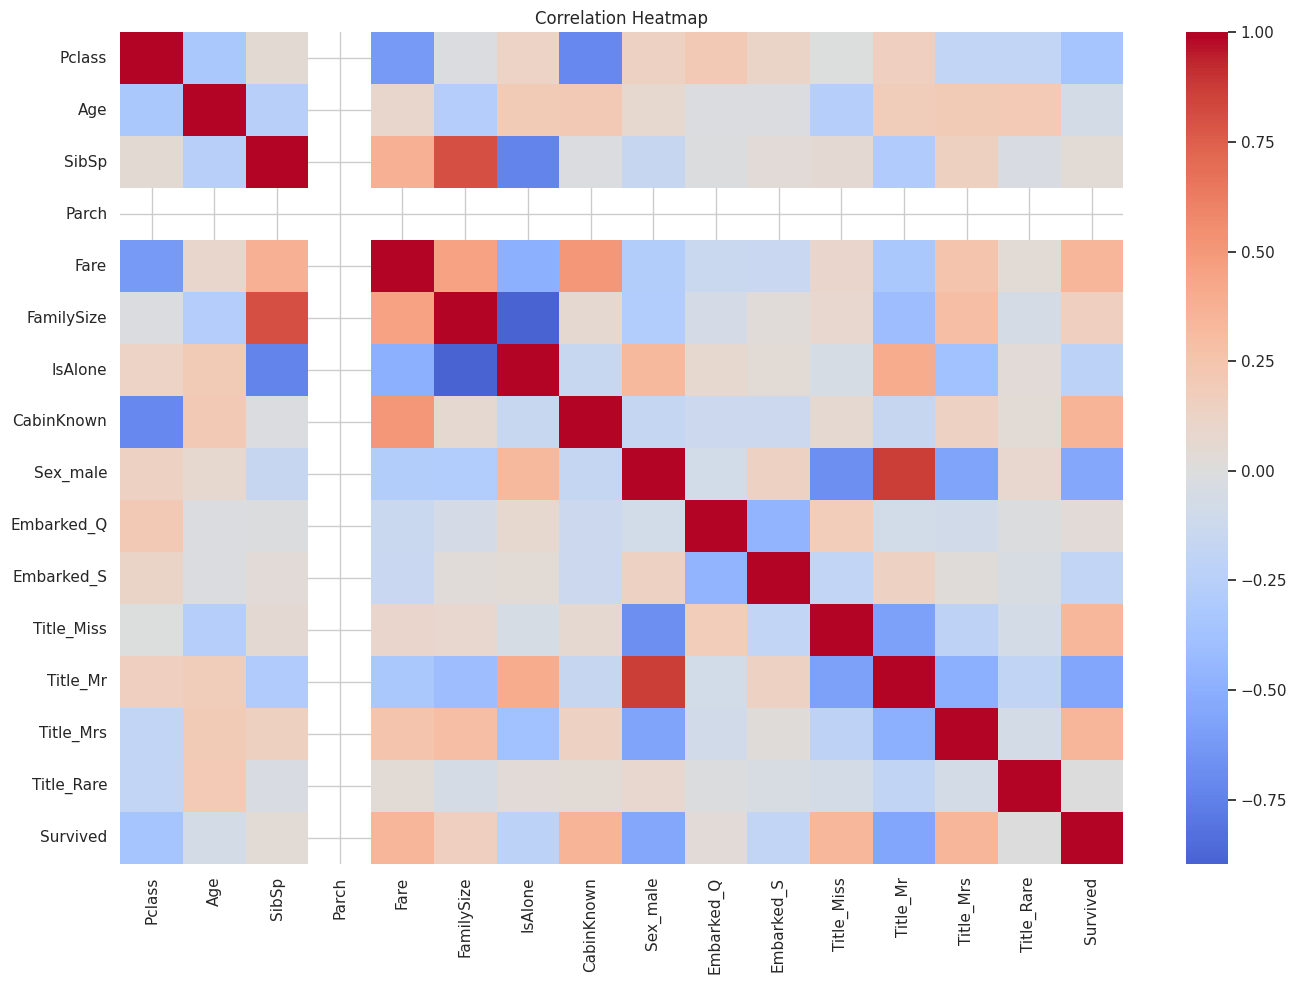


[Survived와의 상관관계]
Survived      1.000000
CabinKnown    0.350535
Fare          0.348151
Title_Mrs     0.347373
Title_Miss    0.336459
FamilySize    0.157535
SibSp         0.039369
Embarked_Q    0.031501
Title_Rare    0.001809
Age          -0.069221
Embarked_S   -0.179163
IsAlone      -0.215570
Pclass       -0.348007
Sex_male     -0.549171
Title_Mr     -0.555587
Parch              NaN
Name: Survived, dtype: float64

========== 모델 평가 결과 ==========
Accuracy: 0.8212
Precision: 0.8136
Recall: 0.6957
F1-score: 0.75
ROC-AUC: 0.8469

[Classification Report]
              precision    recall  f1-score   support

          사망       0.82      0.90      0.86       110
          생존       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179


[혼동행렬]
[[99 11]
 [21 48]]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


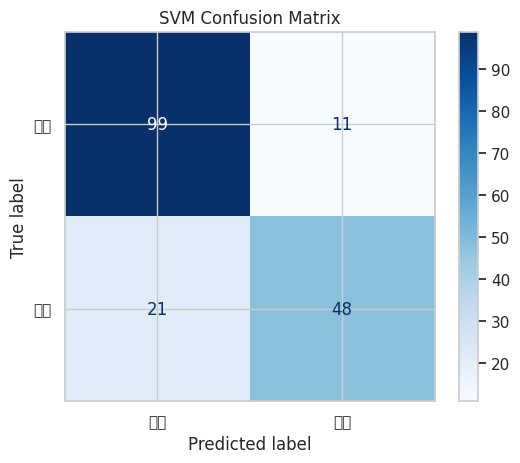

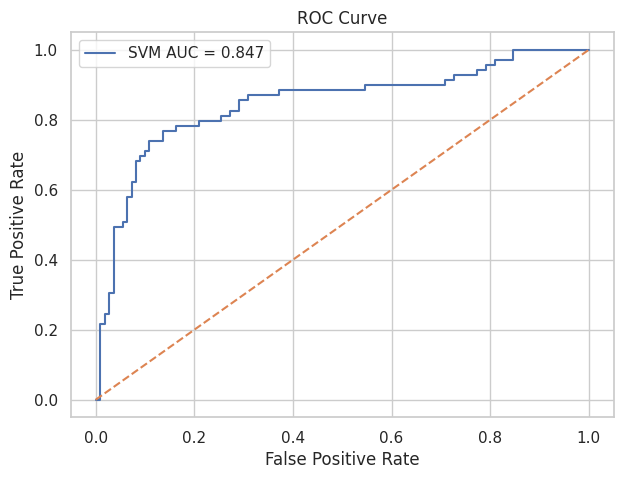


[실제값과 예측값 비교]
    Actual  Predicted  Survival_Probability
0        0          0              0.065050
1        0          0              0.074290
2        1          0              0.159570
3        0          0              0.085451
4        1          1              0.727763
5        1          1              0.551318
6        1          1              0.830150
7        0          0              0.319306
8        0          0              0.347519
9        0          0              0.104818
10       0          0              0.152318
11       0          0              0.084690
12       1          1              0.732302
13       0          0              0.192934
14       0          0              0.399279
15       0          0              0.154528
16       0          0              0.152292
17       0          0              0.149007
18       0          0              0.153547
19       1          1              0.837027

[SVM 커널별 성능 비교]
    Kernel  Accuracy  Precision    Recall  F

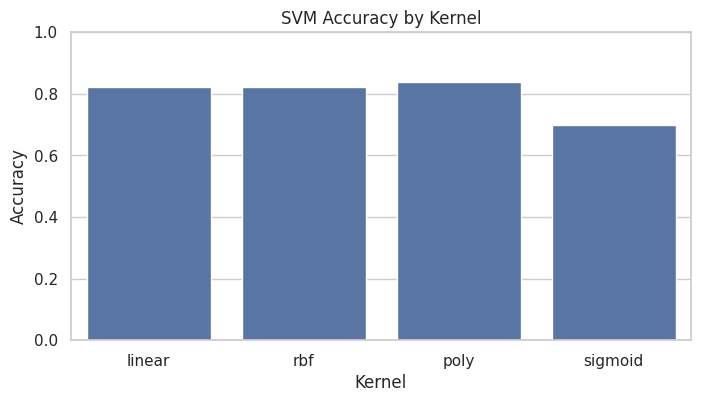

In [36]:


# ============================================================
# 15. 범주형 변수 원-핫 인코딩
# ============================================================

categorical_columns = [
"Sex",
"Embarked",
"Title"
]

X_train = pd.get_dummies(
X_train,
columns=categorical_columns,
drop_first=True,
dtype=int
)

X_test = pd.get_dummies(
X_test,
columns=categorical_columns,
drop_first=True,
dtype=int
)


# 학습 데이터와 테스트 데이터의 컬럼을 동일하게 맞춤
X_train, X_test = X_train.align(
X_test,
join="left",
axis=1,
fill_value=0
)

print("\n[인코딩 후 학습 데이터]")
print(X_train.head())

print("\n[인코딩 후 데이터 크기]")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


# ============================================================
# 16. 표준화
# StandardScaler: 평균 0, 표준편차 1
# ============================================================

scale_columns = [
"Age",
"Fare",
"SibSp",
"Parch",
"FamilySize"
]

scaler = StandardScaler()

X_train[scale_columns] = scaler.fit_transform(
X_train[scale_columns]
)

X_test[scale_columns] = scaler.transform(
X_test[scale_columns]
)

print("\n[표준화 후 데이터]")
print(X_train[scale_columns].head())

print("\n[표준화 후 평균]")
print(X_train[scale_columns].mean())

print("\n[표준화 후 표준편차]")
print(X_train[scale_columns].std())


# ============================================================
# 17. 상관관계 시각화
# ============================================================

train_analysis = X_train.copy()
train_analysis["Survived"] = y_train.values

plt.figure(figsize=(14, 10))

correlation = train_analysis.corr()

sns.heatmap(
correlation,
cmap="coolwarm",
center=0,
annot=False
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# 타겟과의 상관관계
target_correlation = correlation["Survived"].sort_values(
ascending=False
)

print("\n[Survived와의 상관관계]")
print(target_correlation)


# ============================================================
# 18. SVM 모델 학습
# ============================================================

model = SVC(
kernel="rbf",
C=1.0,
gamma="scale",
probability=True,
random_state=42
)

model.fit(
X_train,
y_train
)


# ============================================================
# 19. 예측
# ============================================================

y_pred = model.predict(X_test)

# ROC-AUC 계산을 위한 생존 확률
y_prob = model.predict_proba(X_test)[:, 1]


# ============================================================
# 20. 모델 평가
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n========== 모델 평가 결과 ==========")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))


print("\n[Classification Report]")
print(
classification_report(
y_test,
y_pred,
target_names=["사망", "생존"]
)
)


# ============================================================
# 21. 혼동행렬
# ============================================================

cm = confusion_matrix(
y_test,
y_pred
)

print("\n[혼동행렬]")
print(cm)


display = ConfusionMatrixDisplay(
confusion_matrix=cm,
display_labels=["사망", "생존"]
)

display.plot(
cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.show()


# ============================================================
# 22. ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(
y_test,
y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
fpr,
tpr,
label=f"SVM AUC = {roc_auc:.3f}"
)

plt.plot(
[0, 1],
[0, 1],
linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# ============================================================
# 23. 실제값과 예측값 비교
# ============================================================

result = pd.DataFrame({
"Actual": y_test.values,
"Predicted": y_pred,
"Survival_Probability": y_prob
})

print("\n[실제값과 예측값 비교]")
print(result.head(20))


# ============================================================
# 24. 커널별 SVM 성능 비교
# ============================================================

kernels = [
    "linear",
    "rbf",
    "poly",
    "sigmoid"
]

kernel_results = []

for kernel in kernels:

    compare_model = SVC(
        kernel=kernel,
        C=1.0,
        probability=True,
        random_state=42
    )

    compare_model.fit(
        X_train,
        y_train
    )

    compare_pred = compare_model.predict(
        X_test
    )

    compare_prob = compare_model.predict_proba(
        X_test
    )[:, 1]

    kernel_results.append({
        "Kernel": kernel,
        "Accuracy": accuracy_score(
            y_test,
            compare_pred
        ),
        "Precision": precision_score(
            y_test,
            compare_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            compare_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            compare_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            compare_prob
        )
    })

kernel_result_df = pd.DataFrame(kernel_results)

print("\n[SVM 커널별 성능 비교]")
print(kernel_result_df)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=kernel_result_df,
    x="Kernel",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.title("SVM Accuracy by Kernel")
plt.ylabel("Accuracy")
plt.show()